In [37]:
contrastive_loss_scaler = 50

In [38]:
# import argparse

# def str_to_bool(value):
#     """Convert argument string to boolean."""
#     if isinstance(value, bool):
#         return value
#     if value.lower() in ('true', '1', 'yes', 'y'):
#         return True
#     elif value.lower() in ('false', '0', 'no', 'n'):
#         return False
#     else:
#         raise argparse.ArgumentTypeError("Boolean value expected (true/false or 1/0).")
        
# def int_or_str(val):
#     try:
#         return int(val)
#     except ValueError:
#         return val

# parser = argparse.ArgumentParser()
# parser.add_argument("--index", type=int_or_str, required=True, help="Filename index")
# parser.add_argument("--subset_size", type=float, required=True)
# parser.add_argument("--noadv", type=str_to_bool, required=True)

# parser.add_argument("--max_epochs", type=int, required=True)

# parser.add_argument("--KL_scaling", type=float, required=True)
# parser.add_argument("--n_cat_discriminator_train", type=int, required=True)
# parser.add_argument("--n_pert_discriminator_train", type = int, required = True)
# parser.add_argument("--n_adversarial_start", type = int, required = True)

# parser.add_argument("--cat_dropout", type=float, required=True)

# parser.add_argument("--generator_dropout_rate", type=float, required=True)
# parser.add_argument("--n_layers_vae", type=int, required=True)

# parser.add_argument("--main_max_lr", type=float, required=True)
# parser.add_argument("--gen_max_lr", type=float, required=True)
# parser.add_argument("--cat_max_lr", type=float, required=True)
# parser.add_argument("--pert_max_lr", type=float, required=True)


# parser.add_argument("--cat_max_penalty_weight", type=float, required=True)
# parser.add_argument("--cat_bias_orthogonality_scaler", type=float, required=True)
# parser.add_argument("--cat_bias_lambda_L2", type=float, required=True)

# parser.add_argument("--spectral_loss_factor", type=float, required=True)
# parser.add_argument("--uniform_lambda_L2", type=float, required=True)

# ########################################################################
# args = parser.parse_args()
# fn = str(args.index)

# subset_size = args.subset_size
# no_adv = args.noadv
# vae_scaling_KL = args.KL_scaling
# max_epochs = args.max_epochs
# n_cat_discriminator_train = args.n_cat_discriminator_train
# n_pert_discriminator_train = args.n_pert_discriminator_train
# n_adversarial_start = args.n_adversarial_start
# # pert_spectral_norm = args.pert_spectral_norm
# # cat_spectral_norm = args.cat_spectral_norm

# main_max_lr = args.main_max_lr
# gen_max_lr = args.gen_max_lr
# cat_max_lr = args.cat_max_lr
# pert_max_lr = args.pert_max_lr

# cat_dropout = args.cat_dropout

# generator_dropout_rate = args.generator_dropout_rate
# n_layers_vae = args.n_layers_vae


# cat_max_penalty_weight = args.cat_max_penalty_weight
# cat_bias_orthogonality_scaler = args.cat_bias_orthogonality_scaler
# cat_bias_lambda_L2 = args.cat_bias_lambda_L2 

# spectral_loss_factor = args.spectral_loss_factor
# uniform_lambda_L2 = args.uniform_lambda_L2

# # python test_run.py --index 2 --subset_size 0.05 --noadv false --max_epochs 600 --KL_scaling 5e-5 --n_cat_discriminator_train 5 --n_pert_discriminator_train 5 --cat_dropout 0.1 --n_adversarial_start 200 --main_max_lr 2e-3 --gen_max_lr 5e-4 --cat_max_lr 1e-3 --pert_max_lr 1e-3 --cat_max_penalty_weight 11 --generator_dropout_rate 0.7 --n_layers_vae 3 --cat_bias_orthogonality_scaler 100 --cat_bias_lambda_L2 1e-4 --spectral_loss_factor 1e-6 --uniform_lambda_L2 1e-7



In [39]:
index = 'dev'
subset_size = 0.01
noadv = False
max_epochs = 3
vae_scaling_KL = 5e-5
n_cat_discriminator_train = 5
n_pert_discriminator_train = 5
cat_dropout = 0.1
n_adversarial_start = 0
main_max_lr = 2e-3
gen_max_lr = 5e-4
cat_max_lr = 1e-3
pert_max_lr = 1e-3
cat_max_penalty_weight = 11
generator_dropout_rate = 0.7
n_layers_vae = 3
cat_bias_orthogonality_scaler = 100
cat_bias_lambda_L2 = 1e-4
spectral_loss_factor = 1e-6
uniform_lambda_L2 = 1e-7


In [40]:
import os
import time
import math

from tqdm import tqdm

import pandas as pd
import numpy as np
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import preprocess as pp 
from scLEMBAS.model.train import TrainSC
from scLEMBAS.model.scl import SignalingModel

import Tahoe_utils as Tu

In [41]:
subset = True

In [42]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
mod_seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'

device = "cuda" if torch.cuda.is_available() else "cpu"



Load data:

In [43]:
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', author + '_sn_ppis.csv'), 
                     index_col = 0)
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', author + '_consensus_tf_activity.h5ad'))
adata = sc.read_h5ad(os.path.join(data_path, 'processed', author + '_expr_in.h5ad'))
expr = adata.to_df().copy()

# basic formatting checks
if not np.all(tf_adata.var_names == sorted(tf_adata.var_names)):
    raise ValueError('Ensure TF adata features are sorted on input')
    
if not np.all(adata.obs_names == tf_adata.obs_names):
    raise ValueError('Ensure gene expression and TF activity sample features are orderd the same')
    
if len(set(tf_adata.obs.drug)) != len(tf_adata.obs.drug.cat.categories):
    raise ValueError('Make sure only present perturbations are in the categorical columns')
    
if len(set(tf_adata.obs.cell_line)) != len(tf_adata.obs.cell_line.cat.categories):
    raise ValueError('Make sure only present cell lines are in the categorical columns')

# Train/test split:

In [44]:
train_split, test_split = Tu.Tahoe100M_split(tf_adata,
                                          train_frac = 0.9, 
                                          min_drug_frac = 0.7, 
                                          min_cell_line_frac = 0.7, 
                                          exclude_control = True, 
                                          max_attempts = 1000, 
                                          seed = seed)

train_cells = train_split['barcodes']
test_cells = test_split['barcodes']

cell_line_counts = pd.DataFrame({
    'train': train_split['cell_line_counts'],
    'test': test_split['cell_line_counts']
}).sort_values(by = 'train', ascending = True)

drug_counts = pd.DataFrame({
    'train': train_split['drug_counts'],
    'test': test_split['drug_counts']
}).sort_values(by = 'train', ascending = True)



In [45]:
cell_line_counts

,train,test
cell_line,,
CVCL_0371,23,6
CVCL_0546,24,5
CVCL_1056,24,5
CVCL_0480,26,3
CVCL_1550,26,3
CVCL_0459,27,2
CVCL_1285,27,2
CVCL_0023,28,1
CVCL_0399,28,1


In [46]:
drug_counts

,train,test
drug,,
Neratinib (maleate),8,2
Almonertinib (mesylate),8,2
Tofacitinib (citrate),8,2
Rucaparib (phosphate),8,2
Retinoic acid,8,2
Rapamycin,8,2
Norepinephrine (hydrochloride),8,2
Filgotinib,8,2
Tofacitinib,9,1


Get the PLS models for test prediction projections -- we assume at most the # of components needed to describe the subset is that of the full dataset, so we set that as the number of components, rather than doing the automated elbow selection.

In [47]:
# from scLEMBAS import latent_separation as ls
# import joblib

# ctrl_pert = 'DMSO_TF'
# pls_rank = tf_adata.uns['pls']['model_fit']['n_components']
# pls_models = {}

# pls_fn = os.path.join(
#     data_path, 'trash',
#     '_'.join([author, 'PLSfits', 'seed{}'.format(seed)]) + '.pkl'
# )

# if not os.path.isfile(pls_fn):
#     print('Get PLS model fits')
#     for test_cond in tqdm(tf_adata[test_cells, :].obs.condition.unique()):
#         cell_line, pert = test_cond.split('^')
#         tf_adata_sub, r2_df = ls.pls_da_pipeline(
#             adata = tf_adata, 
#             pert_ids = [pert, ctrl_pert],
#             cat_ids = cell_line,
#             n_components = pls_rank, 
#             pert_col = 'drug', 
#             cat_col = 'cell_line', 
#             separate_by = 'perturbation', 
#             control_confounders = [], 
#             covariate_associations = ['drug'],
#             scale = False, # TF activity already Z-scored
#             run_umap = False, 
#             file_prefix = None, 
#             verbose = True,
#             seed = seed, 
#             n_cores = n_cores
#         )

#         for k in ['pls_mod']: # ['encoder_y', '']:
#             pls_models[test_cond] = {
#                 k: tf_adata_sub.uns['pls'][k]
#             }
# #         pls_models[test_cond]['umap_pls_mod'] = tf_adata_sub.uns['umap_pls']['umap_pls_mod']
#         pls_models[test_cond]['top_components_drug'] = ls.get_top_components(r2_df, top_components_cov = 'drug')

#     joblib.dump(pls_models, pls_fn)
#     del tf_adata_sub

In [48]:
if subset:
    train_cells = []
    np.random.seed(seed)
    for cond in train_split['conditions'].condition:
        subset_cond = tf_adata.obs[tf_adata.obs.condition == cond]
        subset_cells = list(np.random.choice(
            subset_cond.index,
            size = int(np.round(subset_cond.shape[0] * subset_size)),
            replace = False
        ))
        train_cells+=subset_cells
    tf_adata = tf_adata[tf_adata.obs_names.isin(train_cells + test_cells),:].copy()
    adata = adata[tf_adata.obs_names, :].copy()
    expr = adata.to_df().copy()

In [49]:
cat_col = 'cell_line'
pert_col = 'drug'

In [50]:
tf_adata[train_cells, :].obs[cat_col].value_counts().unique()

array([588, 567, 546, 504, 483])

In [51]:
tf_adata[train_cells, :].obs[pert_col].value_counts().unique()

array([210, 189, 168])

**Note: As mentioned in Notebook 00A, when splitting the data into train-test splits, conditions will remain balanced, but drug/cell lines will not be completely balanced (due to OOD, cannot ensure the drug and cell line split is the same as the condition split).** 

# Hyper-parameters:

In [52]:
def generate_lr_params(n_epochs, 
                       max_lr, 
                       lr_scaling_factor=10, 
                       lr_decay=0.75,
                       n_restarts=4,
#                        n_cat_discriminator_train=5,
#                        n_pert_discriminator_train=5,
                       n_adversarial_start=0,
                       role='scl'):
    """
    Generate LR scheduler params for WarmupCosineAnnealingWarmRestarts
    that ensures discriminator and generator follow the same curve in real (epoch) time.

    For 'generator', it updates when either discriminator is active.

    Returns:
        Dict of scheduler parameters
    """

    total_active_epochs = n_epochs
    n_steps = n_epochs  # default for SCL

    if role in ['generator', 'cat_discriminator', 'pert_discriminator']:
        if n_adversarial_start >= n_epochs: # won't be used anyways
            n_adversarial_start = 0
        total_active_epochs = n_epochs - n_adversarial_start
        n_steps = total_active_epochs // 1

#    DEPRECATED: this was necessary when generator trained every n_discriminator_train epochs
#                rather than discriminator training n_discriminator_train times every epoch
#     elif role in 'generator':
#         # Generator steps on any epoch divisible by either cat or pert discriminator schedule
#         effective_epochs = range(n_adversarial_start, n_epochs)
#         n_steps = sum(
#             (e % n_cat_discriminator_train == 0) or (e % n_pert_discriminator_train == 0)
#             for e in effective_epochs
#         )

    T_0 = max(1, n_steps // n_restarts)
    warmup_epochs = max(1, n_steps // 10)

    if warmup_epochs >= T_0:
        warmup_epochs = 0

    return {
        'max_epochs': n_epochs,
        'maximum_learning_rate': max_lr,
        'minimum_learning_rate': max_lr / lr_scaling_factor,
        'lr_restart_epoch': T_0,
        'n_optimizer_resets': 0,
        'lr_decay': lr_decay,
        'lr_restart_factor': 1,
        'warmup_epochs': warmup_epochs
    }


In [53]:
projection_amplitude_in = 10
projection_amplitude_out = 1

bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor': 50, 
                 'tolerance': 1e-5, 
                 'leak': 1e-2}

spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 5, 
                          'subset_n_spectral': 5, 
                         'track_spectral_radius': True}
target_spectral_radius = 0.9

noise_params = {
    'network_noise_scale': 0.01, 
    'min_network_noise': 0.0015, #0.0025, 
    'gradient_noise_scale': 1e-9, 
    'include_gradient_noise_vae': True, 
    'include_gradient_noise_embedding': True, 
    'constant_gradient_noise': True
    
}

In [54]:
loss_scaler = 100
prediction_loss_fn = torch.nn.MSELoss(reduction='mean')


batch_params = {
    'train_batch_size': int(512*8), 
    'test_batch_size': int(512*8), 
    'validation_batch_size': np.nan
}


max_batch_scaler = 24

if subset:
    if subset_size < 0.02:
        batch_scaler = 2
    else:
        batch_scaler = int(8 * round(math.ceil(subset_size / 0.05) * 0.05, 2) / 0.05)
        batch_scaler = min(batch_scaler, max_batch_scaler)

    batch_params['train_batch_size'] = int(512*batch_scaler)
    batch_params['test_batch_size'] = int(512*batch_scaler)
# max_epochs = 600

lr_scaling_factor = 10
lr_decay = 0.9
n_restarts = 4
lr_params = generate_lr_params(n_epochs = max_epochs, 
                               max_lr = main_max_lr, 
                               lr_scaling_factor = lr_scaling_factor, 
                               lr_decay = lr_decay,
                               n_restarts = n_restarts,
                               n_adversarial_start = np.nan, 
#                                n_cat_discriminator_train = np.nan, 
#                                n_pert_discriminator_train = np.nan,
                               role = 'scl')

# reset_state = False # DEPRECATED
# initialize_fc = True # DEPRECATED

In [55]:
bionet_params['cat_max_norm'] = 100
regularization_params = {
    'input_lambda_L2': 0, # irrelevant because setting the requires grad to False
    
    'bn_weights_lambda_L2': 1e-7,
    'moa_lambda_L1': 1e2,
    'uniform_lambda_L2': uniform_lambda_L2, #0, #1e-7, 
    'uniform_min': -1/projection_amplitude_out,
    'uniform_max': 1/projection_amplitude_out,
    'adj_scaling_KL': 0,  # using uniform/bn_weights already
    'adj_prior_mu': 0, # irrelevant because adj_scaling_KL is 0
    'adj_prior_sigma': 0.2, # irrelevant because adj_scaling_KL is 0
    
    'output_weights_lambda_L2': 1e-7,
    'output_bias_lambda_L2': 1e-7,
    
    'spectral_loss_factor': spectral_loss_factor,
    
    
    'global_bias_lambda_L2': 0, # using KL divergence instead
    'global_bias_lambda_L1': 0, # using KL divergence instead
    'cat_bias_lambda_L2': cat_bias_lambda_L2, # 1e-4, # allow for generalization (not collapsing on perturbation)
    'cat_bias_lambda_L1': 0, # using cat max norm
    'contrastive_loss_scaler': contrastive_loss_scaler, # contrastive loss
#     'cat_bias_orthogonality_scaler': cat_bias_orthogonality_scaler
}

cat_pert_params = {'regularization_scaler': cat_bias_orthogonality_scaler, 
                       'method': 'orthogonality', 
                       'per_label': False, 
                       'include_adjacency': False, 
                       'temperature': 0.1
                      }

In [56]:
training_params = {
    **lr_params, 
    **batch_params, 
    **regularization_params, 
    **spectral_radius_params,
    **noise_params
}

training_params['prediction_loss_fn_scaler'] = loss_scaler

VAE:

In [57]:
# building
# n_layers_vae = 1
n_nodes = len(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
vae_n_hidden_nodes = list(np.round(np.linspace(adata.shape[1], n_nodes, n_layers_vae + 2)).astype(int)[1:-1])

# generator_dropout_rate = 0.7
vae_mod_params = {
    'vae_batch_momentum': 0.01, 
    'vae_layer_norm': False, 
    'vae_dropout_rate': generator_dropout_rate,
    'vae_activation_fn': nn.LeakyReLU,
    'vae_n_hidden_nodes': vae_n_hidden_nodes, 
    'vae_var_min': 1e-4

} 
bionet_params = {**bionet_params, **vae_mod_params}

# training
vae_params = {
    'prior_mu': 0, 
    'prior_sigma': 1,
    'scaling_KL': vae_scaling_KL, #1e-2, 
    'lambda_l2': 1e-5, 
    'optimizer': torch.optim.Adam
}

 
n_restarts_adversarial = 4
vae_lr_params = generate_lr_params(n_epochs = max_epochs,
                                   max_lr = gen_max_lr, #max_lr,
                                   lr_scaling_factor = lr_scaling_factor, 
                                   lr_decay = lr_decay,
                                   n_restarts = n_restarts_adversarial,
                                   n_adversarial_start = n_adversarial_start,
#                                n_cat_discriminator_train = n_cat_discriminator_train, 
#                                n_pert_discriminator_train = n_pert_discriminator_train,
                                   role = 'generator')
vae_params = {**vae_params, **vae_lr_params}
del vae_params['max_epochs']


Discriminator:

In [58]:
discriminator_params = {
    'batch_momentum': None,
    'layer_norm': False,
    'spectral_norm': np.nan, #False,
    'dropout_rate': np.nan,
    'activation_fn': nn.LeakyReLU,
    'n_hidden_nodes': np.nan,
    'lr_restart_factor': 1,
    'optimizer': torch.optim.Adam,
    'discriminator_lambda_L2': 1e-3,
    'discriminator_penalty_weight': np.nan, 
    'bionet_activation': False,
    'smooth_labels': True, 
    'epsilon_smooth': np.nan
}

In [59]:
# architecture -- pert >> cat bc harder classification problem
cat_n_layers_disc = 3
cat_disc_n_hidden_nodes = list(np.round(np.linspace(n_nodes, 
                                                    cell_line_counts.shape[0],
                                                    cat_n_layers_disc + 2)).astype(int)[1:-1])
cat_discriminator_params = discriminator_params.copy()
cat_discriminator_params['n_hidden_nodes'] = cat_disc_n_hidden_nodes
cat_discriminator_params['dropout_rate'] = cat_dropout

cat_spectral_norm = True
cat_discriminator_params['spectral_norm'] = cat_spectral_norm
if cat_spectral_norm:
    cat_discriminator_params['discriminator_lambda_L2'] = 0


pert_n_layers_disc = 4
pert_disc_n_hidden_nodes = list(np.round(np.linspace(n_nodes, 
                                                     drug_counts.shape[0], 
                                                     pert_n_layers_disc + 2)).astype(int)[1:-1])

# add 3 additional "starting" layers since classifying perturbation is difficult
pert_disc_n_hidden_nodes = [pert_disc_n_hidden_nodes[0]]*3 + pert_disc_n_hidden_nodes

pert_discriminator_params = discriminator_params.copy()
pert_discriminator_params['n_hidden_nodes'] = pert_disc_n_hidden_nodes
pert_discriminator_params['dropout_rate'] = 0.1

pert_spectral_norm = True
pert_discriminator_params['spectral_norm'] = pert_spectral_norm
if pert_spectral_norm:
    pert_discriminator_params['discriminator_lambda_L2'] = 0

cat_discriminator_params['epsilon_smooth'] = 1/tf_adata.obs.cell_line.nunique()
pert_discriminator_params['epsilon_smooth'] = 1/tf_adata.obs.drug.nunique()

In [60]:
# adverserial penalty curve
# cat_max_penalty_weight = 11
cat_b_adv = 2.5
pert_max_penalty_weight = 10 #15
pert_b_adv = 2 #10

if n_adversarial_start < max_epochs:
    cat_discriminator_params['discriminator_penalty_weight'] = pp.discriminator_weight_curve(
        n_epochs = max_epochs - n_adversarial_start,
        min_penalty_weight = 0.01,
        max_penalty_weight = cat_max_penalty_weight,
        a = 1,
        b = cat_b_adv, 
        curve_type = 'power')

    n_pert_train = int(max_epochs/2)
    pert_discriminator_penalty_weight = [0] * n_pert_train
    pert_discriminator_penalty_weight += pp.discriminator_weight_curve(
        n_epochs = max_epochs - n_pert_train - n_adversarial_start,
        min_penalty_weight = 1e-5,
        max_penalty_weight = pert_max_penalty_weight,
        a = 1,
        b = pert_b_adv, 
        curve_type = 'power')
    pert_discriminator_params['discriminator_penalty_weight'] = pert_discriminator_penalty_weight
else:
    cat_discriminator_params['discriminator_penalty_weight'] = [0]*max_epochs
    pert_discriminator_params['discriminator_penalty_weight'] = [0]*max_epochs




# # DEPRECATED: when n_discriminator_train trained generator less frequently instead of disc more frequently
# def expand_elements(lst, n_discriminator_train):
#     return [x for x in lst for _ in range(n_discriminator_train)]
# n_adj = 1 if n_cat_discriminator_train > 1 else 0
# cat_discriminator_penalty_weight = pp.discriminator_weight_curve(
#     n_epochs = int((max_epochs - n_adversarial_start)/n_cat_discriminator_train) - n_adj,
#     min_penalty_weight = 0.1,
#     max_penalty_weight = cat_max_penalty_weight,
#     a = 1,
#     b = cat_b_adv, 
#     curve_type = 'power')
# cat_discriminator_penalty_weight = expand_elements(cat_discriminator_penalty_weight, n_cat_discriminator_train)
# cat_discriminator_penalty_weight = [0]*n_adj*n_cat_discriminator_train + cat_discriminator_penalty_weight
# cat_discriminator_params['discriminator_penalty_weight'] = cat_discriminator_penalty_weight

# n_pert_train = 300
# pert_discriminator_penalty_weight = [0] * n_pert_train

# n_adj = n_pert_discriminator_train if n_pert_discriminator_train > 1 and n_pert_train == 0 else 0
# pdpw2 = pp.discriminator_weight_curve(
#     n_epochs = int((max_epochs - n_pert_train - n_adversarial_start)/n_pert_discriminator_train) - n_adj,
#     min_penalty_weight = 1e-5,
#     max_penalty_weight = pert_max_penalty_weight,
#     a = 1,
#     b = pert_b_adv, 
#     curve_type = 'power')
# pdpw2 = expand_elements(pdpw2, n_pert_discriminator_train)
# pert_discriminator_penalty_weight += [0]*n_adj*n_pert_discriminator_train + pdpw2


# pert_discriminator_params['discriminator_penalty_weight'] = pert_discriminator_penalty_weight

In [61]:
# discriminator LRs

# categorical
discriminator_lr_params = generate_lr_params(
    n_epochs = max_epochs,
    max_lr = cat_max_lr,
    lr_scaling_factor = lr_scaling_factor, 
    lr_decay = lr_decay,
    n_restarts = n_restarts_adversarial,
    n_adversarial_start = n_adversarial_start, 
#     n_pert_discriminator_train = np.nan,
#     n_cat_discriminator_train = n_cat_discriminator_train,
    role = 'cat_discriminator')
del discriminator_lr_params['max_epochs']

cat_discriminator_params = {**cat_discriminator_params, **discriminator_lr_params}

# perturbation
discriminator_lr_params = generate_lr_params(
    n_epochs = max_epochs,
    max_lr = pert_max_lr,
    lr_scaling_factor = lr_scaling_factor, 
    lr_decay = lr_decay,
    n_restarts = n_restarts_adversarial,
    n_adversarial_start = n_adversarial_start, 
#     n_pert_discriminator_train = n_pert_discriminator_train,
#     n_cat_discriminator_train = np.nan,
    role = 'pert_discriminator')
del discriminator_lr_params['max_epochs']

pert_discriminator_params = {**pert_discriminator_params, **discriminator_lr_params}

Visualize hyperparameters:

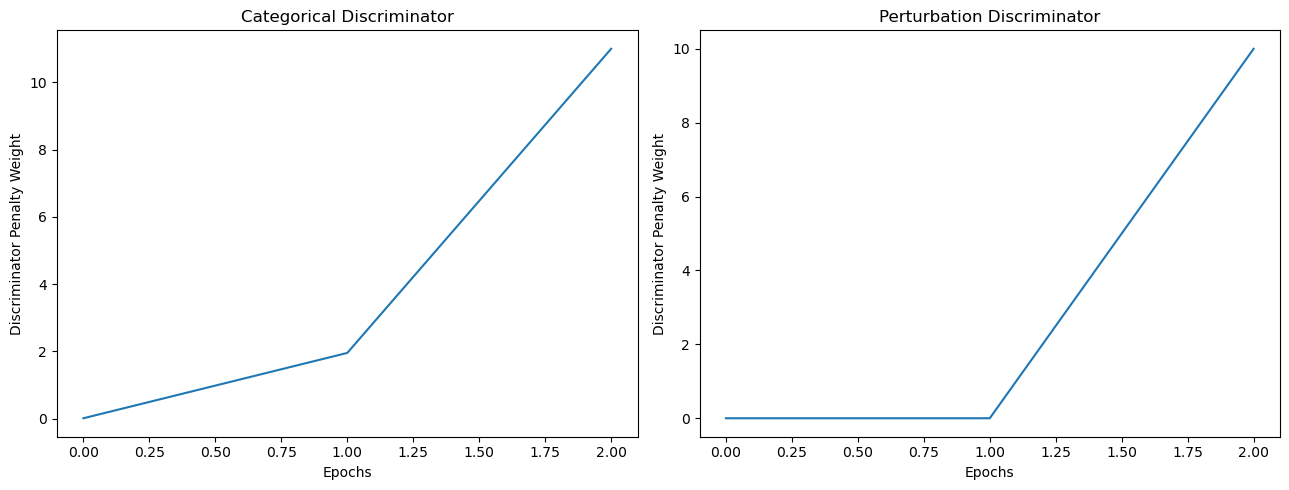

In [62]:
fig, ax = plt.subplots(ncols = 2, figsize = (13,5))
sns.lineplot(cat_discriminator_params['discriminator_penalty_weight'], ax = ax[0])
ax[0].set_title('Categorical Discriminator')

sns.lineplot(pert_discriminator_params['discriminator_penalty_weight'], ax = ax[1])
ax[1].set_title('Perturbation Discriminator')

for i in range(2):
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Discriminator Penalty Weight')
    
fig.tight_layout();

# Build model and trainer

# Start

In [63]:
# input stimulation
X_in = pd.get_dummies(tf_adata.obs.drug).astype(int)
X_in.drop(columns = 'DMSO_TF', inplace = True) # all 0s

In [64]:
mod = SignalingModel(
    net = sn_ppis,
    X_in = X_in,
    y_out = tf_adata.to_df().copy(), 
    expr = expr, 
    covariates = tf_adata.obs.copy(),
    categorical_covariate_keys = ['cell_line'],
    projection_amplitude_in = projection_amplitude_in, 
    projection_amplitude_out = projection_amplitude_out,
    weight_label = weight_label, source_label = source_label, target_label = target_label,
    bionet_params = bionet_params, 
    dtype = torch.float32, device = device, seed = mod_seed)

mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius


In [65]:
trainer = TrainSC(
    mod = mod,
    prediction_optimizer = torch.optim.Adam,
    prediction_loss_fn = prediction_loss_fn, 
    per_condition_loss = False,
    n_adversarial_start = n_adversarial_start, 
n_cat_discriminator_train = n_cat_discriminator_train,
n_pert_discriminator_train = n_pert_discriminator_train,
    gradient_ascent = True,
    cat_discriminator_params = cat_discriminator_params,
    pert_discriminator_params = pert_discriminator_params,
    vae_params = vae_params,
    hyper_params = training_params,
    cat_pert_params = cat_pert_params,
    train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
    train_seed = mod_seed, 
    track_test = True,
    track_validation = False, 
    n_eval_cells = np.nan, 
    n_eval_bootstrap = np.nan
)

In [66]:
mod = trainer.train_model(verbose = True)

 33%|███████████████                              | 1/3 [00:14<00:29, 14.66s/it]

i=0, l(tr)=94.39073, l(te)=nan, s=0.15954, r=0.00020, v=0.00000


100%|█████████████████████████████████████████████| 3/3 [00:44<00:00, 14.67s/it]

Training ran in: 0 min 44.02 sec



/home/hmbaghda/Projects/scLEMBAS/scLEMBAS/model/train.py:2184: UserWarning: Training loss tracking is incorrect
  warnings.warn('Training loss tracking is incorrect')


In [150]:
n_adversarial_start = trainer.n_adversarial_start
n_cat_discriminator_train = trainer.n_cat_discriminator_train
n_pert_discriminator_train = trainer.n_pert_discriminator_train

train_stats_df = trainer.stats['train'].copy()

keep_mask = pd.Series([
    (e >= n_adversarial_start) 
    for e in (train_stats_df.epoch - 1)
])
# # keep_cat_mask = (train_stats_df.epoch - 1) % (n_cat_discriminator_train == 0)
# # keep_pert_mak = (train_stats_df.epoch - 1) % (n_pert_discriminator_train == 0)
# # keep_gen_mask = pd.Series([
# #     (e >= n_adversarial_start) and 
# #     ((e % n_cat_discriminator_train == 0) or (e % n_pert_discriminator_train == 0))
# #     for e in (train_stats_df.epoch - 1)
# # ])

# # masks for n_discriminator_train for visualization
# for col in ['global_bias_kl_divergence', 'vae_param_reg_loss', 'vae_grad_l2_norm']:
#     train_stats_df[col] = train_stats_df[col].mask(
#         (~keep_gen_mask),  # this second condition is a sanity check, shouldn't be necessary
#         np.nan
#     )
    
# # since total is a function of adversarial parameters that also go to 0 on n_discriminator train
# for col in ['train_loss_total']:
#     train_stats_df[col] = train_stats_df[col].mask(
#         (~keep_gen_mask), 
#         np.nan
#     )
    
# similarly, sign reg goes to 0 with 0 violations which makes visualization difficult
# we will ignore those for a smoother curve
for col in ['sign_reg_loss']:
    train_stats_df[col] = train_stats_df[col].mask(
        (train_stats_df[col] == 0), 
        np.nan
    )

# DELETE THIS
train_stats_df = train_stats_df.groupby('epoch').mean().reset_index() 

    
cat_col = 'cell_line'
pert_col = 'drug'
ctrl_pert = 'DMSO_TF'
    
train_cells = trainer.X_train.index.tolist()
test_cells = trainer.X_test.index.tolist()

train_conds = sorted(tf_adata.obs.loc[train_cells, :].condition.unique())
test_conds = sorted(tf_adata.obs.loc[test_cells, :].condition.unique())

# subset_size = round(len(train_cells)/(tf_adata.n_obs*0.9), 2)
pls_fn = os.path.join(
    data_path, 'trash',
    '_'.join([author, 'PLSfits', 'seed{}'.format(seed)]) + '.pkl'
)
pls_models = joblib.load(pls_fn)

In [157]:
# # train_stats_df['contrastive_loss'] = 0
train_stats_df['uniform_reg_loss'] = 0

In [153]:
train_stats_df['contrastive_loss']

0    44.995918
1    28.438698
2    81.260066
Name: contrastive_loss, dtype: float64

/tmp/ipykernel_1289982/1683315659.py:176: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


''

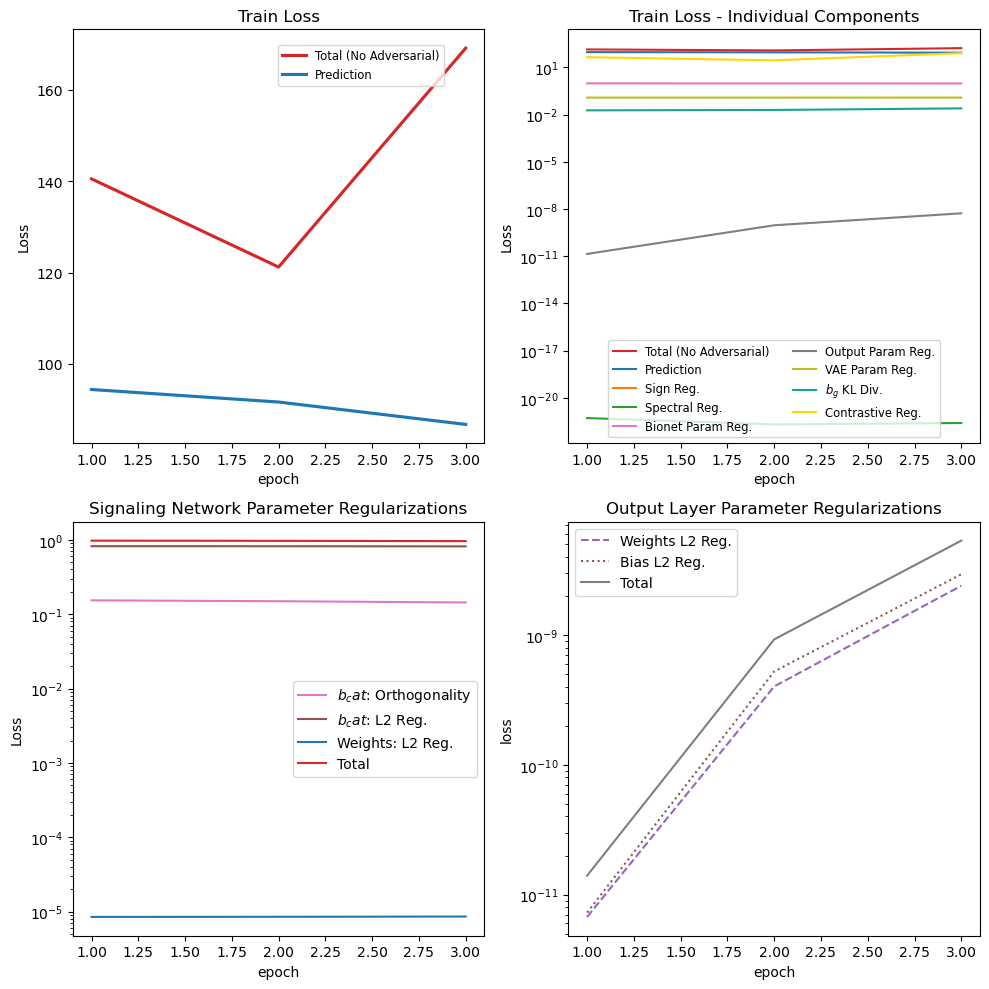

In [143]:
from matplotlib.lines import Line2D


[(0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.6470588235294118, 0.5372549019607843),
 (0.4196078431372549, 0.6823529411764706, 0.8392156862745098)]

In [108]:
viz_df.loss_type.cat.remove_unused_categories()

0                 Prediction
1                 Prediction
2                 Prediction
3                  Sign Reg.
4                  Sign Reg.
5                  Sign Reg.
6              Spectral Reg.
7              Spectral Reg.
8              Spectral Reg.
9               Uniform Reg.
10              Uniform Reg.
11              Uniform Reg.
12          Contrastive Reg.
13          Contrastive Reg.
14          Contrastive Reg.
18         Bionet Param Reg.
19         Bionet Param Reg.
20         Bionet Param Reg.
21         Output Param Reg.
22         Output Param Reg.
23         Output Param Reg.
24            VAE Param Reg.
25            VAE Param Reg.
26            VAE Param Reg.
27             $b_g$ KL Div.
28             $b_g$ KL Div.
29             $b_g$ KL Div.
30    Total (No Adversarial)
31    Total (No Adversarial)
32    Total (No Adversarial)
Name: loss_type, dtype: category
Categories (10, object): ['Total (No Adversarial)' < 'Prediction' < 'Sign Reg.' < 'Spectral Reg.'

/tmp/ipykernel_1289982/1662038086.py:78: UserWarning: The palette list has more values (12) than needed (11), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[i])
/tmp/ipykernel_1289982/1662038086.py:164: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


''

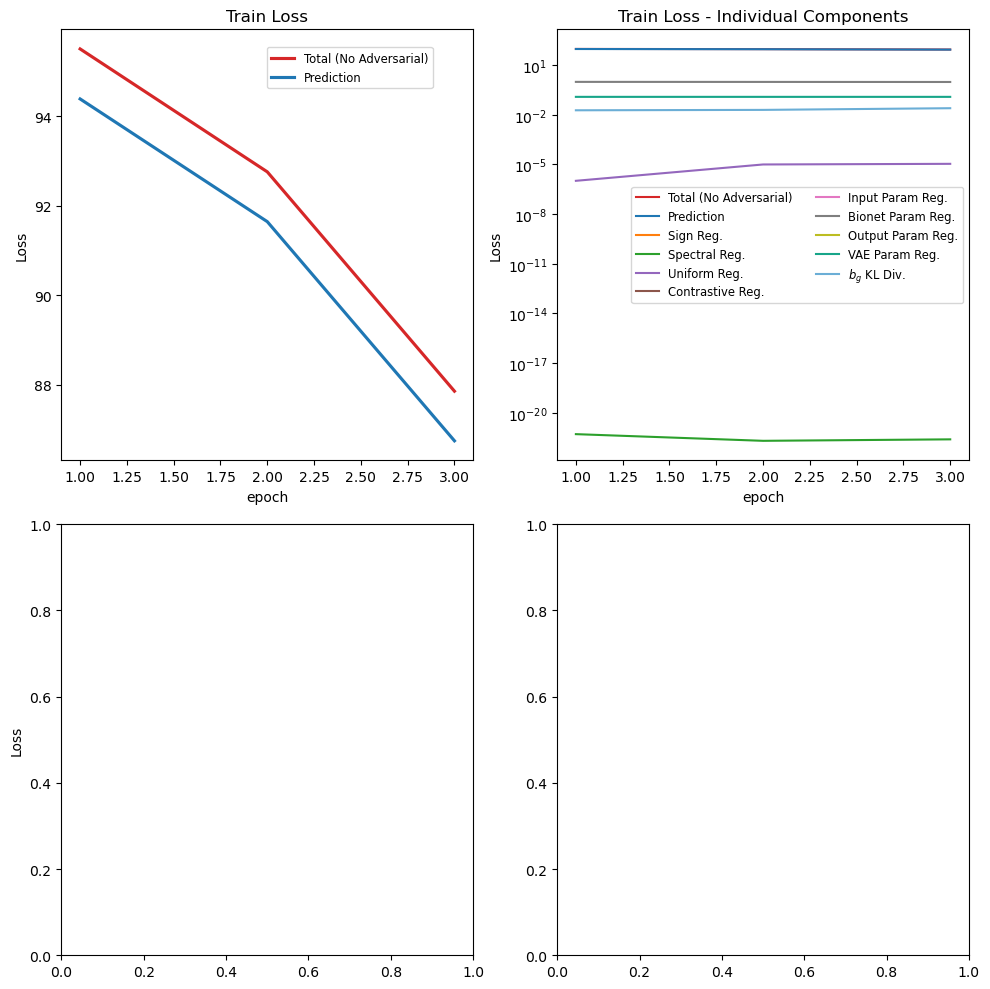

In [87]:
fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (10, 10), 
                        constrained_layout=True)
ax = axes.flatten()

colors = [
    "#d62728",  # Red
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17a589",  #  Teal 
    "#6baed6",  # light blue
    "#ff9896"   # Light red
]
palette = sns.color_palette(colors)

# prediction loss
i = 0

loss_cols_main = [
       'train_loss_prediction', 'sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'contrastive_loss', 'input_param_reg_loss',
       'sn_param_reg_tot_loss', 'output_param_reg_tot_loss', 'vae_param_reg_loss', 
    'global_bias_kl_divergence']

viz_df = train_stats_df[['epoch'] + loss_cols_main].copy()
viz_df['total_train_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)

# # otherwise, they are too similar on the non discriminator training portions
# keep_idx = (viz_df.epoch - 1) % n_discriminator_train == 0
# for col in ['total_train_loss_no_adverserial', 'train_loss_prediction']:
#     viz_df[col] = viz_df[col].mask(
#         (~keep_idx),  
#         np.nan
#     )

viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, 
                                  categories=['total_train_loss_no_adverserial'] + loss_cols_main)


loss_map = {
    'train_loss_prediction': 'Prediction', 
    'sign_reg_loss': 'Sign Reg.', 
    'stability_reg_loss': 'Spectral Reg.', 
    'uniform_reg_loss': 'Uniform Reg.', 
    'contrastive_loss': 'Contrastive Reg.',
    'input_param_reg_loss': 'Input Param Reg.', 
    'sn_param_reg_tot_loss': 'Bionet Param Reg.', 
    'output_param_reg_tot_loss': 'Output Param Reg.', 
    'vae_param_reg_loss': 'VAE Param Reg.', 
    'global_bias_kl_divergence': r'$b_g$' + ' KL Div.', 
    'total_train_loss_no_adverserial': 'Total (No Adversarial)'
}
viz_df.loss_type = viz_df.loss_type.map(loss_map)


loss_cols_sub = ['Total (No Adversarial)', 'Prediction']

# viz_df = viz_df[viz_df.loss_type.isin(loss_cols_sub)]
# viz_df.loss_type = viz_df.loss_type.cat.remove_unused_categories()

for lti, loss_type in enumerate(loss_cols_sub):
    sns.regplot(data = viz_df[viz_df.loss_type == loss_type], 
                x = 'epoch', y = 'loss', 
                lowess = True, scatter = False, 
                color = palette[lti], ax = ax[i], label = loss_type)
ax[i].legend(loc='lower center', bbox_to_anchor=(0.7, 0.85), ncol = 1, fontsize = 'small')
ax[i].set_title('Train Loss')

# all losses
i = 1

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[i])
ax[i].legend(ncol = 2, fontsize = 'small')
ax[i].set_title('Train Loss - Individual Components')
ax[i].set_yscale('log')


# # signaling network weights and bias by individual components (except global bias KL divergence visualized above)
# i = 2
# loss_cols = [
#     'sn_param_reg_tot_loss',
#     'sn_param_reg_weights_L2_loss',
#     'sn_param_reg_weights_kl_divergence',
#     'sn_param_reg_global_bias_L2_loss', 
#     'sn_param_reg_global_bias_L1_loss',
#     'sn_param_reg_cat_bias_L2_loss', 
#     'sn_param_reg_cat_bias_L1_loss',
#     'sn_param_reg_cat_bias_pert'][::-1]
# palette = ['tab:red', 'tab:blue', 'tab:purple', 'tab:orange', 'tab:cyan', 'tab:brown', 'tab:olive',
#            (0.8901960784313725, 0.4666666666666667, 0.7607843137254902)][::-1]

# viz_df = train_stats_df[['epoch'] + loss_cols].copy()
# viz_df = viz_df.melt(id_vars=['epoch'], var_name='loss_type', value_name='loss')
# viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered=True, categories=loss_cols)

# loss_cols_name = [
#     'Total',
#     'Weights: L2 Reg.',
#     'Weights: KL Divergence',
#     r'$b_g$:' ' L2 Reg.',
#     r'$b_g$:' ' L1 Reg.',
#     r'$b_cat$:' ' L2 Reg.',
#     r'$b_cat$:' ' L1 Reg.',
#     r'$b_cat$:' ' Orthogonality'][::-1]
# loss_map = dict(zip(loss_cols, loss_cols_name))
# viz_df.loss_type = viz_df.loss_type.map(loss_map)

# zeros = viz_df.groupby('loss_type').loss.apply(lambda x: (x == 0).all())
# zeros = np.array(zeros.index)[np.where(zeros)]
# viz_df = viz_df[~viz_df.loss_type.isin(zeros)]
# viz_df.loss_type = viz_df.loss_type.cat.remove_unused_categories()
# palette = [col for i,col in enumerate(palette) if loss_cols_name[i] in viz_df.loss_type.cat.categories]
# palette = dict(zip(viz_df.loss_type.cat.categories, palette))

# for lt in viz_df.loss_type.cat.categories:
#     viz_df_ = viz_df[viz_df.loss_type == lt]
#     sns.lineplot(data = viz_df_, x = 'epoch', y = 'loss', 
#                  color = palette[lt], 
#                  ax = ax[i])
# ax[i].set_title('Signaling Network Parameter Regularizations')
# ax[i].set_yscale('log')
# legend_handles = [Line2D([0], [0], color=palette[lt], label=lt) for lt in viz_df.loss_type.cat.categories]

# ax[i].legend(handles=legend_handles, loc = 'best')

# i = 3
# loss_cols = ['output_param_reg_weights_loss', 'output_param_reg_bias_loss', 'output_param_reg_tot_loss']
# palette = ['tab:purple', 'tab:brown', 
#            (0.4980392156862745, 0.4980392156862745, 0.4980392156862745)]
# linestyles = ['--', 'dotted', 'solid']


# viz_df = train_stats_df[['epoch'] + loss_cols].copy()
# viz_df = viz_df.melt(id_vars=['epoch'], var_name='loss_type', value_name='loss')
# viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered=True, categories=loss_cols)

# loss_cols_name = ['Weights L2 Reg.', 'Bias L2 Reg.', 'Total']
# palette = dict(zip(loss_cols_name, palette))
# linestyles = dict(zip(loss_cols_name, linestyles))

# viz_df.loss_type = viz_df.loss_type.map(dict(zip(loss_cols, loss_cols_name)))


# for lt in loss_cols_name:
#     viz_df_ = viz_df[viz_df.loss_type == lt]
#     sns.lineplot(data = viz_df_, x = 'epoch', y = 'loss', 
#                  color = palette[lt], linestyle = linestyles[lt],
#                  ax = ax[i])
# ax[i].set_title('Output Layer Parameter Regularizations')
# ax[i].set_yscale('log')
# legend_handles = [Line2D([0], [0], color=palette[lt], linestyle=linestyles[lt], label=lt) for lt in loss_cols_name]
# ax[i].legend(handles=legend_handles, loc = 'best')

for i in range(3):
    ax[i].set_ylabel('Loss')


fig.tight_layout() 
# plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_all' + '.png'), dpi=300, bbox_inches='tight')

;


In [71]:
trainer.hyper_params['contrastive_loss_scaler']

50

In [34]:
self = trainer
from scLEMBAS.model.train import *

In [35]:
start_time = time.time()
self.mod.signaling_network.implement_mask() # shouldn't be necessary bc called in signaling_network init

torch.autograd.set_detect_anomaly(True)

for e in trange(self.hyper_params['max_epochs']):
    self._run_adv = (self.n_adversarial_start <= e)


    cur_lr = self.prediction_optimizer.param_groups[0]['lr']
    self.cat_discriminator['_cur_lr'] = self.cat_discriminator['optimizer'].param_groups[0]['lr']
    self.pert_discriminator['_cur_lr'] = self.pert_discriminator['optimizer'].param_groups[0]['lr']
    self.vae_learning['_cur_lr'] = self.vae_learning['optimizer'].param_groups[0]['lr']

    cur_catdisc_lambda = self.cat_discriminator['params']['discriminator_penalty_weight'][e] if self._run_adv else self._zero.clone()
    cur_pertdisc_lambda = self.pert_discriminator['params']['discriminator_penalty_weight'][e] if self._run_adv else self._zero.clone()

    # self._run_adv = (
    #     (e >= self.n_adversarial_start)
    #     and (cur_catdisc_lambda != 0 or cur_pertdisc_lambda != 0)
    # )



    # iterate through batches
    if self.mod.seed:
        utils.set_seeds(self.mod.seed + e)
    break
for batch, (X_in_, y_out_, covariates_idx_, expr_) in enumerate(self.train_dataloader):
    break
    

  0%|                                                     | 0/3 [00:00<?, ?it/s]


In [36]:


# set train mode or not (discriminator done below)
self.mod.train()
if not self._run_adv:
    freeze_model(self.mod.signaling_network.vae)
else:
    unfreeze_model(self.mod.signaling_network.vae)

self.prediction_optimizer.zero_grad()
self.cat_discriminator['optimizer'].zero_grad()
self.pert_discriminator['optimizer'].zero_grad()
self.vae_learning['optimizer'].zero_grad()

X_in_, y_out_, covariates_idx_, expr_ = X_in_.to(self.mod.device), y_out_.to(self.mod.device), covariates_idx_.to(self.mod.device), expr_.to(self.mod.device)

######################## Forward Pass ########################
X_full = self.mod.input_layer(X_in_) # transform to full network with ligand input concentrations

# add noise to ninput
utils.set_seeds(self.mod.seed + self.mod._gradient_seed_counter)
network_noise = torch.randn(X_full.shape, device = X_full.device)
noise_scale_factor = self.hyper_params['network_noise_scale'] * (cur_lr/self.lr_scheduler.max_lr)
noise_scale_factor = max(noise_scale_factor, self.hyper_params['min_network_noise'])
X_full = X_full + (noise_scale_factor * network_noise) # randomly add noise to signaling network input, makes model more robust                Y_full, bias_terms = self.mod.signaling_network(X_full = X_full, 

if self._run_adv:
    Y_full, bias_terms, rnn_iter_t = self.mod.signaling_network(X_full = X_full, 
                                                    covariates_idx = covariates_idx_, 
                                                    expr = expr_) # train signaling network weights
    bias_global, bias_mu, bias_log_sigma_squared = bias_terms
else:
    Y_full, _, rnn_iter_t = self.mod.signaling_network.forward_novar(X_full = X_full, 
                                                    covariates_idx = covariates_idx_, 
                                                    expr = expr_) # train signaling network weights

Y_hat = self.mod.output_layer(Y_full)



In [37]:
covariates_idx = covariates_idx_
X_in = X_in_
y_out = y_out_

# z_score = False
# detach_ctrl_grad = True # prevents model from adjusting control predictions to achieve perturbation sep, places burden of adjustment on perturbation
# use centroid, assuming global bias deals with variance

# underestimate_scale = 0.8 # scales understaimates more strongly than overestimeates

# min_percentile = 0.25 # minimum percentile of actual y norms to regularize against (those below this get regularized)



# to do: per cell difference vs centroids


In [38]:
underestimate_only = True

In [47]:
assert X_in.sum(axis = 1).max() <= 1, 'contrastive loss can currently only handle 1 perturbation per cell'

In [44]:
X_in.shape

torch.Size([1024, 28])

In [50]:
len(losses)

1

In [ ]:
if len(losses) != 0:
    

tensor(0.0439, device='cuda:0', grad_fn=<MeanBackward0>)

In [40]:
def contrastive_perturbation_loss(Y_hat, y_out, X_in, covariates_idx, 
                           lambda_scaler: float, 
                           underestimate_only: bool = True, 
                          ):
    """Regularizes each perturbation to encourage separation from control within the category. 

    1) For each category and predicted perturbation condition, calculates the centroid of the 
    perturbation (predicted and actual) and the respective control perturbation (actual only).
    2) Calculates the Euclidean distance between perturbed centroid and the control centroid for 
    predicted and actual data. 
    3) Calculates the loss as the square error between the predicted distance and actual distance.
    4) Takes the mean across conditions. 

    Considerations:
    - prediction contrast anchors to actual controls rather than predicted controls
    - only controls are contrasted, not pairwise
    - centroids are used, rather than individual points

    Parameters
    ----------
    Y_hat : _type_
        the predicted output (samples x features)
    y_out : _type_
        the actual output (samples x features)
    X_in : _type_
        the one-hot encoded perturbations (samples x features)
    covariates_idx : _type_
        the discrete representation of categorical covariate (samples x 1) 
        * can only currently handle one categorical covariate
    lambda_scaler : float, 
        scaling term for the loss
    underestimate_only : bool, optional
        whether to regularize distances only if they are underestimates, by default True

    Returns
    -------
    regularization_loss
        the regularization term
    """
    if lambda_scaler == 0:
        return Y_hat.new_tensor(0.0)
    
    assert X_in.sum(axis = 1).max() <= 1, 'contrastive loss can currently only handle 1 perturbation per cell'
    assert covariates_idx.size(1) == 1, "Contrastive regularization is currently only designed for one categorical covariate"

    # flatten covariates
    cats = covariates_idx.squeeze(1)

    control_mask = (X_in.abs().sum(dim=1) == 0)
    pert_mask = ~control_mask
    pert_ids = X_in.argmax(dim=1)  # [N], valid even if row is control (but we’ll mask)

    losses = []
    # all (cell, pert) combos present in this batch (among perturbed rows)
    combos = torch.stack([cats[pert_mask], pert_ids[pert_mask]], dim=1).unique(dim=0)
    for cat, pid in combos:
        cat_mask = (cats == cat)
        ctrl_cat_mask = cat_mask & control_mask
        cp_mask = cat_mask & (pert_ids == pid) & pert_mask # need and pert_mask when using argmax

        n_ctrl = int(ctrl_cat_mask.sum().item())
        n_pert = int(cp_mask.sum().item())

        if n_ctrl == 0 or n_pert == 0:
            continue

    #     # control centroids (pred and true, kept separate)
    #     pred_ctrl_centroid = Y_hat[ctrl_cat_mask].mean(dim=0, keepdim=True)
    #     if detach_ctrl_grad:
    #         pred_ctrl_centroid = pred_ctrl_centroid.detach()
        actual_ctrl_centroid = y_out[ctrl_cat_mask].mean(dim=0, keepdim=True)

        # per (cat, pert) centroids
        pred_pert_centroid = Y_hat[cp_mask].mean(dim=0, keepdim=True)
        actual_pert_centroid = y_out[cp_mask].mean(dim=0, keepdim=True)

        # distances: pred vs pred_ctrl, target vs true_ctrl
        pred_dist = torch.norm(pred_pert_centroid - actual_ctrl_centroid, p=2)
        target_dist = torch.norm(actual_pert_centroid - actual_ctrl_centroid, p=2)

        if not underestimate_only or (underestimate_only and target_dist > pred_dist):
            loss = torch.square(target_dist - pred_dist) # squared deviation with asymmetric weighting
            losses.append(loss)
        else:
            continue

    
    if len(losses) != 0:
        return lambda_scaler * torch.stack(losses).mean()
    else:
        return Y_hat.new_tensor(0.0)



considerations to think abotu tomorrow!!:
- whether to use predicted controls (AND whether to detach) or true controls --> look at projections to see where the predictions are landing <-- separation on predicted controls will encourage the actual predicetd space separation !! look at the magnitudes of both to judge which would be best...
- whether to use centroids or individual points for predictions --> centroids penalize direction as well, but are simpler; individual just penalizes only distance --> same, look at projections and consider
- whether to consider pairwise distance between all perturbations...
- maybe magnitude + direction of invidiual perts will give better contorl, or magnitude of individual..

see last point here: https://chatgpt.com/c/68ca85e0-b9e4-8327-9f7f-6669bf847937

# End

In [29]:
if not no_adv:
    trainer = TrainSC(
        mod = mod,
        prediction_optimizer = torch.optim.Adam,
        prediction_loss_fn = prediction_loss_fn, 
        per_condition_loss = False,
        n_adversarial_start = n_adversarial_start, 
    n_cat_discriminator_train = n_cat_discriminator_train,
    n_pert_discriminator_train = n_pert_discriminator_train,
        gradient_ascent = True,
        cat_discriminator_params = cat_discriminator_params,
        pert_discriminator_params = pert_discriminator_params,
        vae_params = vae_params,
        hyper_params = training_params,
        cat_pert_params = cat_pert_params,
        train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
        train_seed = mod_seed, 
        track_test = True,
        track_validation = False, 
        n_eval_cells = np.nan, 
        n_eval_bootstrap = np.nan
    )
    
    if not os.path.isfile(os.path.join(data_path, 'trash', fn + author +  '_trainer.pickle')):
        mod = trainer.train_model(verbose = True)
        io.write_pickled_object(trainer, os.path.join(data_path, 'trash', fn + author +  '_trainer.pickle'))

else:
    pdp_noadv = pert_discriminator_params.copy()
    cdp_noadv = cat_discriminator_params.copy()

    pdp_noadv['discriminator_penalty_weight'] = 0.0
    cdp_noadv['discriminator_penalty_weight'] = 0.0

    trainer_noadv = TrainSC(
        mod = mod,
        prediction_optimizer = torch.optim.Adam,
        prediction_loss_fn = prediction_loss_fn, 
        per_condition_loss = False,
        n_adversarial_start = n_adversarial_start, 
    n_cat_discriminator_train = n_cat_discriminator_train,
    n_pert_discriminator_train = n_pert_discriminator_train,
        gradient_ascent = True,
        cat_discriminator_params = cdp_noadv,
        pert_discriminator_params = pdp_noadv,
        vae_params = vae_params,
        hyper_params = training_params,
        cat_pert_params = cat_pert_params,
        train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
        train_seed = mod_seed, 
        track_test = True,
        track_validation = False, 
        n_eval_cells = np.nan, 
        n_eval_bootstrap = np.nan
    )
    
    if not os.path.isfile(os.path.join(data_path, 'trash', fn + author +  '_trainer.pickle')):
        mod_noadv = trainer_noadv.train_model(verbose = True)
        io.write_pickled_object(trainer_noadv, os.path.join(data_path, 'trash', fn + author +  '_trainer.pickle'))    

 33%|███████████████                              | 1/3 [00:06<00:13,  6.56s/it]

i=0, l(tr)=89.44150, l(te)=nan, s=0.25973, r=0.00020, v=0.00000


100%|█████████████████████████████████████████████| 3/3 [00:19<00:00,  6.51s/it]


Training ran in: 0 min 19.53 sec


In [ ]:
import papermill as pm
from nbconvert import HTMLExporter
import nbformat
import os

input_notebook = 'test_visualize.ipynb' # in the current directory
output_notebook = os.path.join(data_path, 'trash', fn +  '_' + author + '.ipynb')
output_html = os.path.join(data_path, 'trash', fn + '_' + author + '.html')

pm.execute_notebook(
    input_path=input_notebook,
    output_path=output_notebook,
    parameters={"fn": fn}, 
    kernel_name='python3'
)

nb = nbformat.read(output_notebook, as_version=4)
html_exporter = HTMLExporter()
html_exporter.exclude_input = True  # <-- hides code cells
(body, _) = html_exporter.from_notebook_node(nb)

with open(output_html, "w", encoding="utf-8") as f:
    f.write(body)
    
os.remove(output_notebook)